In [49]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\isabe_8m\OneDrive\Desktop\Fall_25\501\UFO_Group_Project\DATA-501-Group-Project-UFO-Sightings-Data-Analysis\data\kaggle_ufo_data\scrubbed.csv"
)

df.head()


C:\Users\isabe_8m\AppData\Local\Temp\ipykernel_17172\3956203988.py:3: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611



# Is the rise in UFO reports mainly a reporting artifact driven by internet access and online submission?

Findings for the report are at the bottom.

In [3]:
import pandas as pd

data = pd.read_csv(
    r"C:\Users\isabe_8m\OneDrive\Desktop\Fall_25\501\UFO_Group_Project\DATA-501-Group-Project-UFO-Sightings-Data-Analysis\data\ntia-analyze-table.csv"
)

data.head()

,dataset,variable,description,universe,usProp,usPropSE,usCount,usCountSE,age314Prop,age314PropSE,...,WVCount,WVCountSE,WIProp,WIPropSE,WICount,WICountSE,WYProp,WYPropSE,WYCount,WYCountSE
0,Nov 1994,isHouseholder,Household Reference Person in Universe: Non-In...,NaN,1.000000,0.000000,99708018,233531,NaN,NaN,...,752405,29310,1.000000,0.000000,1916700,70578,1.000000,0.000000,183476,7697
1,Nov 1994,isPerson,Person in Universe: Ages 3+ Not Active-Duty Mi...,NaN,1.000000,0.000000,248509799,723058,1.0,0.0,...,1770883,45537,1.000000,0.000000,4984995,107785,1.000000,0.000000,448994,10524
2,Nov 1994,computerAtHome,"Anyone in Household Uses a Desktop, Laptop, or...",isHouseholder,0.242794,0.002097,24208471,216845,NaN,NaN,...,121779,11590,0.242546,0.015910,464888,35003,0.296431,0.019261,54388,4207
3,Nov 1994,isAdult,Person Ages 15+,isPerson,0.810185,0.001394,201338994,512792,0.0,0.0,...,1474123,34048,0.789043,0.011042,3933376,71314,0.801415,0.011327,359831,7207
4,Oct 1997,isHouseholder,Household Reference Person in Universe: Non-In...,NaN,1.000000,0.000000,102741556,223547,NaN,NaN,...,751435,28669,1.000000,0.000000,2024459,76656,1.000000,0.000000,197046,8005


In [4]:
data['variable'].unique()


array(['isHouseholder', 'isPerson', 'computerAtHome', 'isAdult',
       'internetAnywhere', 'internetAtHome', 'internetUser',
       'homeInternetUser', 'schoolInternetUser', 'workInternetUser',
       'libCommInternetUser', 'homeEverOnline', 'noInternetAtHome',
       'dialUpAtHome', 'wiredHighSpeedAtHome', 'jobSearchUser',
       'eCommerceUser', 'onlineClassUser', 'financeUser',
       'canUseElsewhereMainReason', 'noNeedInterestMainReason',
       'noComputerMainReason', 'tooExpensiveMainReason',
       'satelliteAtHome', 'privSecMainReason', 'unavailableMainReason',
       'mobileAtHome', 'affordabilityMostImportant',
       'serviceMostImportant', 'ispBundle', 'mobilityMostImportant',
       'reliabilityMostImportant', 'speedMostImportant', 'desktopUser',
       'pcOrTabletUser', 'laptopUser', 'mobilePhoneUser', 'tvBoxUser',
       'tabletUser', 'homePhoneInBundle', 'tvInBundle',
       'healthRecordsUser', 'healthInfoUser', 'teleworkUser', 'emailUser',
       'locationServicesUs

Choosing the most relevant variables from NTIA internet data first, then graphing their use by year

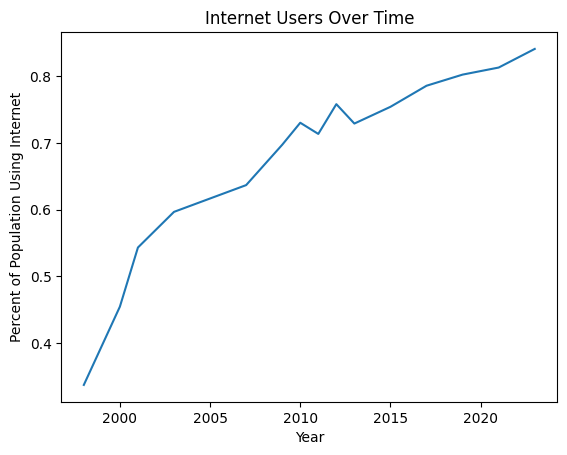

In [7]:
#extracting internetUser (can use internet from any location) 
internet_user = data[data['variable'] == 'internetUser'].copy()

#extract year from the 'dataset' column
internet_user['year'] = internet_user['dataset'].str.extract(r'(\d{4})').astype(int)

#averaging usProp per year
user_yearly = (
    internet_user
    .groupby('year')['usProp']
    .mean()
    .reset_index()
)

#  Plot internet users over time
plt.plot(user_yearly['year'], user_yearly['usProp'])
plt.title("Internet Users Over Time")
plt.xlabel("Year")
plt.ylabel("Percent of Population Using Internet")
plt.show()

Compare to UFO dataset

In [9]:

sightings = pd.read_csv(
    r"C:\Users\isabe_8m\OneDrive\Desktop\Fall_25\501\UFO_Group_Project\DATA-501-Group-Project-UFO-Sightings-Data-Analysis\data\kaggle_ufo_data\scrubbed.csv"
)

sightings.head()

C:\Users\isabe_8m\AppData\Local\Temp\ipykernel_26336\3991695828.py:1: DtypeWarning: Columns (5,9) have mixed types. Specify dtype option on import or set low_memory=False.
  sightings = pd.read_csv(


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [10]:
#convert datetime column to dates
sightings['datetime'] = pd.to_datetime(sightings['datetime'], errors='coerce')

#extract year from datetime column
sightings['year'] = sightings['datetime'].dt.year

#count sightings per year
sightings_per_year = (
    sightings
    .groupby('year')
    .size()
    .reset_index(name='sightings_count')
)

#keep only years that kaggle dataset has data for (1994-2023)
sightings_per_year = sightings_per_year[
    (sightings_per_year['year'] >= 1994) & (sightings_per_year['year'] <= 2014)]

sightings_per_year.head()

,year,sightings_count
66,1994.0,417
67,1995.0,1066
68,1996.0,826
69,1997.0,1242
70,1998.0,1739


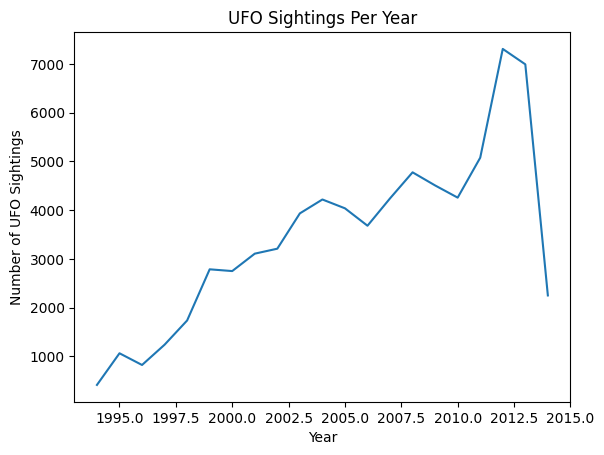

In [11]:
#plotting sightings per year
plt.plot(sightings_per_year['year'], sightings_per_year['sightings_count'])
plt.title("UFO Sightings Per Year")
plt.xlabel("Year")
plt.ylabel("Number of UFO Sightings")
plt.show()

Figuring out where the datasets overlap, using *user_yearly* at the technology variable and *sightings* as the UFO variable.

In [29]:
user_yearly['year'].min(), user_yearly['year'].max()


(np.int64(1998), np.int64(2023))

In [30]:
sightings_per_year['year'].min(), sightings_per_year['year'].max()


(np.float64(1994.0), np.float64(2014.0))

The data will cover 1998 - 2014. Now, I am going to filter both datasets to fit that range.

In [31]:
internet_overlap = user_yearly[
    (user_yearly['year'] >= 1998) &
    (user_yearly['year'] <= 2014)
]

ufo_overlap = sightings_per_year[
    (sightings_per_year['year'] >= 1998) &
    (sightings_per_year['year'] <= 2014)
]


In [32]:
combined = pd.merge(
    ufo_overlap[['year', 'sightings_count']],
    internet_overlap[['year', 'usProp']],
    on='year',
    how='inner'
)


Creating a dual-axis plot to compare the two variables 

Text(0, 0.5, 'Internet Users (%)')

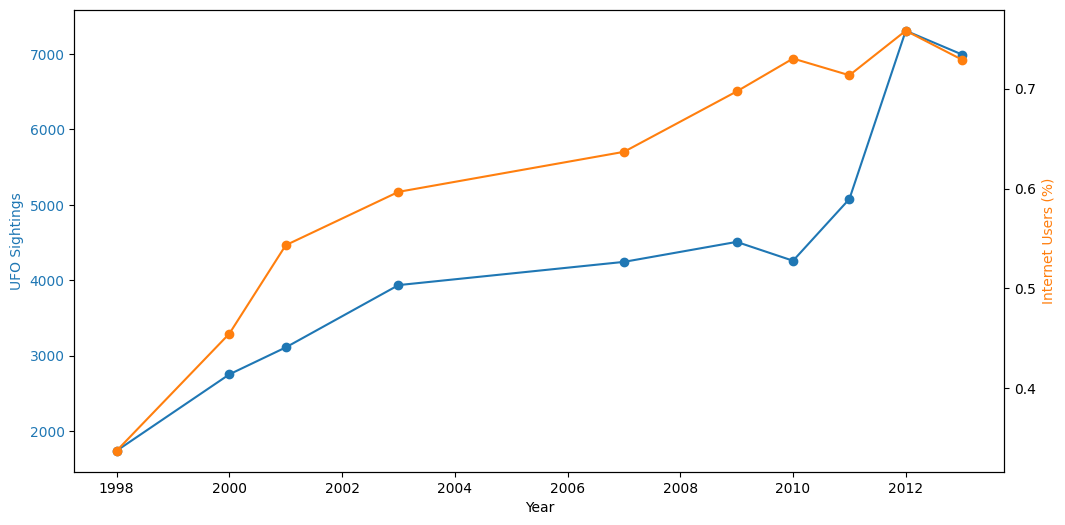

In [35]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Left axis — UFO sightings
ax1.plot(combined['year'], combined['sightings_count'], color='tab:blue', marker='o', label='UFO Sightings')
ax1.set_xlabel("Year")
ax1.set_ylabel("UFO Sightings", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right axis — Internet Users
ax2 = ax1.twinx()
ax2.plot(combined['year'], combined['usProp'], color='tab:orange', marker='o', label='Internet Users (%)')
ax2.set_ylabel("Internet Users (%)", color='tab:orange')



The data shows that UFO sighting reports increased during the same period that internet access became widespread. This supports the interpretation that the rise in sightings is partly due to improved ability to report online rather than a real increase in UFO events.

# Findings

The NTIA (National Telecommunications and Information Administration) dataset measures internet and computer adoption in the United States using surveys conducted between 1998 and 2023. For this analysis, we focused on the internetUsers variable, which represents the percentage of people who use the internet from any location, not just at home or work. This variable matters because greater internet access would make it easier for people to submit UFO reports quickly and consistently. To compare these trends with actual UFO reporting behavior, we used the NUFORC (National UFO Reporting Center) dataset from Kaggle, which contains reported UFO sightings from 1906 to 2014. We extracted annual sighting counts from 1998 to 2014 to match the years covered by the NTIA data. Looking at these datasets together helps us evaluate whether increases in internet adoption may have contributed to the rise in reported UFO sightings.

When examining the internetUsers data on its own, the trend shows a steady and rapid increase in internet use beginning in the late 1990s. Internet adoption continues to rise throughout the early and mid 2000s as personal computers and cellular devices become more common and accessible, with internet fitting in peoples' pockets. By 2012, a large majority of Americans were using the internet regularly, compared to much lower levels at the start of the time period.

The NUFORC data shows a similar upward trend in reported UFO sightings. Sightings rise from fewer than 2,000 in 1998 to well over 7,000 by 2012. The largest increases happen in the same period when internet use is growing the fastest. After 2012, sightings begin to level out instead of continuing upward, which also matches the slowing growth of internet adoption once most households were already online.

The relationship between the two datasets becomes clearer when plotting them together. The combined chart shows that both internet usage and UFO sighting counts increase along nearly the same timeline from 1998 to 2012. In years when internet use jumps significantly, UFO reports tend to show similar increases. Both trends then stabilize around the same time. This pattern suggests that the growth in internet access likely made it easier for people to report sightings through online forms, which NUFORC began using during this period. Before that, reporting a sighting required calling a hotline or sending a written message, which may have discouraged some people from reporting.

Overall, these findings support the idea that the rise in UFO sighting reports from 1998 to 2014 is influenced in part by increasing access to the internet. The similarity between the two trends points to changes in reporting behavior rather than a sudden increase in actual UFO events. The growth of internet use appears to have played an important role in how many sightings were documented during this time.